<a href="https://colab.research.google.com/github/twomathematicians-code/mahesh-portfolio/blob/main/ViVAE_Dimensionality_Reduction_PBMC-scRNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ViVAE Dimensionality Reduction — PBMC scRNA-seq Assignment (Mahesh)

**Course:** Big Data Science  
**Project:** Dimensionality Reduction for Visualization using ViVAE  
**Implementation:** [ViVAE (Saeyslab, Ghent University)](https://github.com/saeyslab/ViVAE)  
**Dataset:** Peripheral Blood Mononuclear Cells (PBMC) — 10x Genomics scRNA-seq

This notebook covers the full project pipeline:
1. **Setup & Data Loading** — Google Drive, install deps, PBMC3k / PBMC68k, stratified subsampling
2. **Preprocessing** — QC, normalisation, HVG selection, PCA
3. **Baseline Embeddings** — UMAP, t-SNE, PaCMAP reference embeddings with timing
4. **ViVAE Training & Scalability** — Training across 1k/3k/5k/10k/20k/68k; wall-clock & GPU memory benchmarking
5. **Quantitative Evaluation** — kNN-recall, trustworthiness, silhouette, ViScore (Local/Global SP), xNPE
6. **Hyperparameter Sweep** — latent_dim, beta (KL weight), hidden_dims, learning_rate
7. **Latent Space Interpretation** — encoder indicatrices, generative traversal, prior sampling, decoder sensitivity, SHAP
8. **Final Outputs & Plotting** — Publication-quality figures & summary table

---

## 0. Environment Setup

In [53]:
%%capture
!pip install scanpy umap-learn pacmap shap scikit-learn seaborn leidenalg
!pip install git+https://github.com/saeyslab/ViVAE.git
!pip install git+https://github.com/saeyslab/FlowSOM_Python.git
!pip install git+https://github.com/saeyslab/ViScore.git
!pip install "pyemd==2.0.0" --force-reinstall --no-cache-dir --no-deps
!pip install POT --no-cache-dir
print('\n[OK] All dependencies installed (including ViScore and ViVAE).')

In [45]:
!pip install --quiet pacmap umap-learn scanpy
print('[OK] Dependencies verified.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 14.2 MB/s eta 0:00:00
[OK] Dependencies verified.


In [54]:
import os
import time
import tracemalloc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import scanpy as sc
import anndata as ad
import umap
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
import pacmap

os.environ['VIVAE_DETERMINISTIC'] = '0'
os.environ['VIVAE_MPS'] = '0'
os.environ['VIVAE_CUDA'] = '1'

import torch
import vivae as vv
import viscore as vs

# UMAP compatibility patch for scikit-learn 1.6+
import sklearn.utils.validation
import umap.umap_ as umap_module
_original_check_array = sklearn.utils.validation.check_array
def _patched_check_array(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return _original_check_array(*args, **kwargs)
umap_module.check_array = _patched_check_array
print('Patch applied: UMAP is now compatible with scikit-learn 1.6+')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU device:      {torch.cuda.get_device_name(0)}')
    print(f'GPU memory:      {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'ViVAE device:    {vv.DEVICE_NAME}')
print(f'Deterministic:   {vv.DETERMINISTIC}')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11, 'figure.facecolor': 'white',
})
sns.set_style('whitegrid')
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

Patch applied: UMAP is now compatible with scikit-learn 1.6+
PyTorch version: 2.10.0+cpu
CUDA available:  False
ViVAE device:    cpu
Deterministic:   True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/ViVAE_Project'
for subfolder in ['data', 'models', 'results', 'figures']:
    os.makedirs(os.path.join(DRIVE_BASE, subfolder), exist_ok=True)

print(f'[OK] Project directory: {DRIVE_BASE}')

import pickle
def save_checkpoint(data, filename, drive_path=DRIVE_BASE):
    with open(filename, 'wb') as f:
        pickle.dump(data, f)
    drive_file = os.path.join(drive_path, 'data', filename)
    with open(drive_file, 'wb') as f:
        pickle.dump(data, f)
    print(f'  Checkpoint saved: {filename} + Drive copy')

def load_checkpoint(filename, drive_path=DRIVE_BASE):
    drive_file = os.path.join(drive_path, 'data', filename)
    if os.path.exists(drive_file):
        with open(drive_file, 'rb') as f:
            print(f'  Checkpoint loaded from Drive: {filename}')
            return pickle.load(f)
    elif os.path.exists(filename):
        with open(filename, 'rb') as f:
            print(f'  Checkpoint loaded locally: {filename}')
            return pickle.load(f)
    return None

Mounted at /content/drive
[OK] Project directory: /content/drive/MyDrive/ViVAE_Project


---

## 1. Data Loading & Preprocessing

We use **PBMC3k** from 10x Genomics (via Scanpy, pre-annotated with 8 cell types) and the full **PBMC68k** dataset.

Preprocessing pipeline: QC -> normalise (10K) -> log1p -> HVG (2,000) -> scale -> PCA (50 components).

The 50-PC matrix is the input **X** for all dimensionality reduction methods.

In [4]:
def stratified_subsample(adata, target_n, label_key, random_state=42):
    labels = adata.obs[label_key]
    unique_labels = labels.unique()
    n_per_label = target_n // len(unique_labels)
    remainder = target_n % len(unique_labels)
    indices = []
    rng = np.random.RandomState(random_state)
    shuffled_labels = rng.permutation(unique_labels)
    for i, lbl in enumerate(shuffled_labels):
        label_indices = np.where(labels == lbl)[0]
        n = n_per_label + (1 if i < remainder else 0)
        if len(label_indices) >= n:
            chosen = rng.choice(label_indices, size=n, replace=False)
        else:
            chosen = label_indices
        indices.extend(chosen.tolist())
    indices = indices[:target_n]
    return adata[indices].copy()

def preprocess(adata, n_hvg=2000, n_pcs=50, label_col='louvain'):
    adata = adata.copy()
    sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=n_hvg, flavor='seurat')
    adata_hvg = adata[:, adata.var['highly_variable']].copy()
    sc.pp.scale(adata_hvg, max_value=10)
    n_pcs_actual = min(n_pcs, adata_hvg.n_obs - 1, adata_hvg.n_vars - 1)
    sc.tl.pca(adata_hvg, svd_solver='arpack', n_comps=n_pcs_actual)
    pc = adata_hvg.obsm['X_pca']
    labels = None
    if label_col in adata.obs.columns:
        labels = np.array(adata.obs[label_col])
    return pc, labels, adata_hvg

print('Helper functions defined.')

Helper functions defined.


### 1.1 PBMC3k - Load and preprocess

In [5]:
import scanpy as sc
adata_3k_raw = sc.datasets.pbmc3k()
processed = sc.datasets.pbmc3k_processed()
common_cells = adata_3k_raw.obs_names.intersection(processed.obs_names)
adata_3k_raw = adata_3k_raw[common_cells].copy()
adata_3k_raw.obs['louvain'] = processed[common_cells].obs['louvain']

print(f'PBMC3k raw loaded: {adata_3k_raw.shape[0]} cells x {adata_3k_raw.shape[1]} genes')
display(adata_3k_raw.obs.head())

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

PBMC3k raw loaded: 2638 cells x 32738 genes


,louvain
index,
AAACATACAACCAC-1,CD4 T cells
AAACATTGAGCTAC-1,B cells
AAACATTGATCAGC-1,CD4 T cells
AAACCGTGCTTCCG-1,CD14+ Monocytes
AAACCGTGTATGCG-1,NK cells


In [6]:
adata_3k_raw = sc.datasets.pbmc3k()
processed = sc.datasets.pbmc3k_processed()
common_cells = adata_3k_raw.obs_names.intersection(processed.obs_names)
adata_3k_raw = adata_3k_raw[common_cells].copy()
adata_3k_raw.obs['louvain'] = processed[common_cells].obs['louvain']
print(f'PBMC3k raw: {adata_3k_raw.shape[0]} cells x {adata_3k_raw.shape[1]} genes')
print(f'Available annotations: {list(adata_3k_raw.obs.columns)}')

PBMC3k raw: 2638 cells x 32738 genes
Available annotations: ['louvain']


In [7]:
pc_3k, labs_3k, adata_3k_pp = preprocess(adata_3k_raw, n_hvg=2000, n_pcs=50, label_col='louvain')
print(f'PBMC3k processed: {pc_3k.shape[0]} cells, PCA shape: {pc_3k.shape}')
print(f'Cell types: {np.unique(labs_3k)}')

PBMC3k processed: 2638 cells, PCA shape: (2638, 50)
Cell types: ['B cells' 'CD14+ Monocytes' 'CD4 T cells' 'CD8 T cells' 'Dendritic cells'
 'FCGR3A+ Monocytes' 'Megakaryocytes' 'NK cells']


### 1.2 PBMC68k - Load and build scaled subsets

We download the PBMC68k dataset and create stratified subsampled versions for scalability testing.

In [8]:
%%bash
# Download the PBMC68k dataset
wget https://cf.10xgenomics.com/samples/cell-exp/1.1.0/fresh_68k_pbmc_donor_a/fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz

# Extract the tarball
tar -xzf fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz

echo "[OK] Data downloaded and extracted."

[OK] Data downloaded and extracted.


--2026-04-27 11:46:25--  https://cf.10xgenomics.com/samples/cell-exp/1.1.0/fresh_68k_pbmc_donor_a/fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 124442812 (119M) [application/x-tar]
Saving to: ‘fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz’

     0K .......... .......... .......... .......... ..........  0% 29.1M 4s
    50K .......... .......... .......... .......... ..........  0% 4.51M 15s
   100K .......... .......... .......... .......... ..........  0% 4.90M 18s
   150K .......... .......... .......... .......... ..........  0% 12.1M 16s
   200K .......... .......... .......... .......... ..........  0% 9.19M 15s
   250K .......... .......... .......... .......... ..........  0% 13.0M 14s
   300K .......... .......... .

In [9]:
%%bash
# Download the PBMC68k dataset from 10x Genomics
wget -q https://cf.10xgenomics.com/samples/cell-exp/1.1.0/fresh_68k_pbmc_donor_a/fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz

# Extract the tarball
tar -xzf fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz

echo "[OK] PBMC68k data downloaded and extracted to 'filtered_matrices_mex/hg19/'"

[OK] PBMC68k data downloaded and extracted to 'filtered_matrices_mex/hg19/'


In [10]:
PBMC68K_PATH = 'pbmc68k.h5ad'
MTX_DIR = 'filtered_matrices_mex/hg19/'

if os.path.exists(PBMC68K_PATH):
    adata_68k = sc.read_h5ad(PBMC68K_PATH)
    print(f'Loaded from cache: {adata_68k.shape}')
elif os.path.exists(MTX_DIR):
    print('Reading 10x MTX files (this may take a moment)...')
    adata_68k = sc.read_10x_mtx(MTX_DIR, var_names='gene_symbols', cache=True)
    adata_68k.var_names_make_unique()
    adata_68k.write_h5ad(PBMC68K_PATH, compression='gzip')
    print(f'Saved to {PBMC68K_PATH}: {adata_68k.shape}')
else:
    # If the directory is missing, re-run download
    !wget -q https://cf.10xgenomics.com/samples/cell-exp/1.1.0/fresh_68k_pbmc_donor_a/fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz
    !tar -xzf fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz
    adata_68k = sc.read_10x_mtx(MTX_DIR, var_names='gene_symbols', cache=True)
    adata_68k.var_names_make_unique()
    adata_68k.write_h5ad(PBMC68K_PATH, compression='gzip')
    print(f'Downloaded and Saved to {PBMC68K_PATH}: {adata_68k.shape}')

print(f'\nadata_68k: {adata_68k.shape[0]:,} cells x {adata_68k.shape[1]:,} genes')

Reading 10x MTX files (this may take a moment)...
Saved to pbmc68k.h5ad: (68579, 32738)

adata_68k: 68,579 cells x 32,738 genes


In [40]:
import numpy as np
import os
import scanpy as sc

RANDOM_STATE = 42
SIZES = {'1k': 1000, '3k': 3000, '5k': 5000, '10k': 10000, '20k': 20000, '68k': 68000}
datasets = {}

# 1. Load and prepare PBMC3k
print('Loading and Processing PBMC3k...')
adata_3k_raw = sc.datasets.pbmc3k()
processed_3k = sc.datasets.pbmc3k_processed()
common_cells = adata_3k_raw.obs_names.intersection(processed_3k.obs_names)
adata_3k_raw = adata_3k_raw[common_cells].copy()
adata_3k_raw.obs['louvain'] = processed_3k[common_cells].obs['louvain']

pc_3k, labs_3k, _ = preprocess(adata_3k_raw, n_hvg=2000, n_pcs=50, label_col='louvain')
datasets['3k'] = {'pc': pc_3k, 'labs': labs_3k}
print(f'PBMC3k: {pc_3k.shape[0]} cells, PC shape {pc_3k.shape}')

# 2. Load 68k for further subsets
PBMC68K_PATH = 'pbmc68k.h5ad'
if os.path.exists(PBMC68K_PATH):
    adata_68k = sc.read_h5ad(PBMC68K_PATH)
    print(f'Loaded adata_68k from {PBMC68K_PATH}')

    # Generate labels if missing
    label_key_68k = 'leiden' if 'leiden' in adata_68k.obs.columns else 'louvain'
    if label_key_68k not in adata_68k.obs.columns:
        print('Clustering PBMC68k to generate labels...')
        sc.pp.normalize_total(adata_68k, target_sum=1e4)
        sc.pp.log1p(adata_68k)
        sc.pp.highly_variable_genes(adata_68k, n_top_genes=2000)
        sc.tl.pca(adata_68k)
        sc.pp.neighbors(adata_68k)
        sc.tl.leiden(adata_68k, key_added='leiden')
        label_key_68k = 'leiden'

    for label in ['1k', '5k']:
        n = SIZES[label]
        sub = stratified_subsample(adata_68k, n, label_key_68k, random_state=RANDOM_STATE)
        pc, labs, _ = preprocess(sub, n_hvg=2000, n_pcs=50, label_col=label_key_68k)
        datasets[label] = {'pc': pc, 'labs': labs}
        print(f'PBMC{label}: {pc.shape[0]} cells, PC shape {pc.shape}')

    save_checkpoint(datasets, 'checkpoint_datasets.pkl')
    print('\n[OK] Required datasets preprocessed and saved.')
else:
    print(f'[Error] {PBMC68K_PATH} not found.')

Loading and Processing PBMC3k...


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

Selecting HVGs...


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


...

Selecting HVGs...


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PBMC1k: 996 cells, PC shape (996, 50)
Selecting HVGs...


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


PBMC5k: 4749 cells, PC shape (4749, 50)
  Checkpoint saved: checkpoint_datasets.pkl + Drive copy

[OK] Required datasets preprocessed and saved.


In [41]:
if '10k' not in datasets:
    print('Preparing PBMC10k subset...')
    # Use Leiden or Louvain labels for stratified sampling
    label_key = 'leiden' if 'leiden' in adata_68k.obs.columns else 'louvain'

    # Subsample 10,000 cells
    sub_10k = stratified_subsample(adata_68k, 10000, label_key, random_state=RANDOM_STATE)

    # Preprocess (Normalization, HVG, PCA)
    pc_10k, labs_10k, _ = preprocess(sub_10k, n_hvg=2000, n_pcs=50, label_col=label_key)

    # Store in the global datasets dictionary
    datasets['10k'] = {'pc': pc_10k, 'labs': labs_10k}

    print(f'[OK] PBMC10k defined. PCA shape: {pc_10k.shape}')
else:
    print('PBMC10k already exists in datasets.')

Preparing PBMC10k subset...
Selecting HVGs...


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


[OK] PBMC10k defined. PCA shape: (8939, 50)


---

## 2. Baseline Embeddings - UMAP, t-SNE, PaCMAP

We run all three reference methods on each dataset size with wall-clock timing.

In [42]:
def run_baselines(pc, seed=42, verbose=True):
    results = {}
    if verbose: print('  Running t-SNE...', end=' ')
    t0 = time.time()
    results['tSNE'] = TSNE(n_components=2, perplexity=30, random_state=seed,
                            learning_rate='auto', init='pca').fit_transform(pc)
    results['tSNE_time'] = time.time() - t0
    if verbose: print(f'{results["tSNE_time"]:.1f}s')
    if verbose: print('  Running UMAP...', end=' ')
    t0 = time.time()
    model_umap = umap.UMAP(n_components=2, random_state=seed)
    results['UMAP'] = model_umap.fit_transform(pc)
    results['UMAP_time'] = time.time() - t0
    results['UMAP_model'] = model_umap
    if verbose: print(f'{results["UMAP_time"]:.1f}s')
    if verbose: print('  Running PaCMAP...', end=' ')
    t0 = time.time()
    model_pacmap = pacmap.PaCMAP(n_components=2, random_state=seed)
    results['PaCMAP'] = model_pacmap.fit_transform(pc)
    results['PaCMAP_time'] = time.time() - t0
    if verbose: print(f'{results["PaCMAP_time"]:.1f}s')
    return results

In [56]:
import pandas as pd
import time
import os
import pickle
import umap
import pacmap
from sklearn.manifold import TSNE

# Ensure datasets are loaded
if 'datasets' not in globals() or datasets is None:
    datasets = load_checkpoint('checkpoint_datasets.pkl')

# We specifically need 3k results
label = '3k'
if datasets and label in datasets:
    n_cells = datasets[label]['pc'].shape[0]
    print(f'\nProcessing PBMC{label} ({n_cells} cells) for baselines...')

    # Run baselines
    bl = run_baselines(datasets[label]['pc'])

    if 'all_baselines' not in globals(): all_baselines = {}
    all_baselines[label] = bl

    if 'baseline_times' not in globals(): baseline_times = {sz: {} for sz in SIZES}
    for method in ['tSNE', 'UMAP', 'PaCMAP']:
        if f'{method}_time' in bl:
            baseline_times[label][method] = bl[f'{method}_time']

    save_checkpoint({'all_baselines': all_baselines, 'baseline_times': baseline_times}, 'checkpoint_baselines.pkl')
    print(f'[OK] Baselines for PBMC{label} restored.')
else:
    print(f'[Error] PBMC{label} dataset not found. Please re-run the data loading cell.')


Processing PBMC3k (2638 cells) for baselines...
  Running t-SNE... 33.0s
  Running UMAP... 

12.3s
  Running PaCMAP... 1.3s
  Checkpoint saved: checkpoint_baselines.pkl + Drive copy
[OK] Baselines for PBMC3k restored.


---

## 3. ViVAE Training & Scalability Benchmarking

We train ViVAE on each dataset size using the official API with k-NN denoising.

Recommended scRNA-seq settings: lam_mds=100, lam_recon=1.0, n_epochs=100.

In [47]:
def train_vivae(pc, n_epochs=100, batch_size=512, latent_dim=2,
                hidden_dims=[32, 64, 128, 32],
                learning_rate=1e-3, lam_kldiv=1.0,
                lam_mds=100.0, lam_recon=1.0,
                seed=42, verbose=False):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    k_knn = min(1000, pc.shape[0] - 1)
    k_smooth = min(50, pc.shape[0] - 1)
    print(f'Constructing k-NNG', end=' ')
    knn = vv.make_knn(x=pc, k=k_knn)
    pc_dn = vv.smooth(x=pc, knn=knn, k=k_smooth, coef=1., n_iter=1)
    model = vv.ViVAE(input_dim=pc.shape[1], latent_dim=latent_dim,
                     hidden_dims=hidden_dims, random_state=seed)
    tracemalloc.start()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    t0 = time.time()
    model.fit(X=pc_dn, n_epochs=n_epochs, batch_size=batch_size,
              learning_rate=learning_rate, lam_kldiv=lam_kldiv,
              lam_mds=lam_mds, lam_recon=lam_recon, verbose=verbose)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    wall_t = time.time() - t0
    _, peak_cpu = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_cpu_mb = peak_cpu / 1024**2
    peak_gpu_mb = torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else 0.0
    emb = model.transform(pc_dn)
    return emb, model, pc_dn, knn, wall_t, peak_cpu_mb, peak_gpu_mb

In [57]:
vivae_results = {}
vivae_times = {}
vivae_mems_cpu = {}
vivae_mems_gpu = {}

# We specifically need to restore/re-run 3k for the evaluation
label = '3k'
if 'datasets' in globals() and label in datasets:
    n_cells = datasets[label]['pc'].shape[0]
    print(f'Training ViVAE on PBMC{label} ({n_cells} cells)...', end=' ')
    bs = min(512, n_cells)
    emb, model, pc_dn, knn, t, mem_cpu, mem_gpu = train_vivae(
        datasets[label]['pc'], n_epochs=100, batch_size=bs)
    vivae_results[label] = {'emb': emb, 'model': model, 'pc_dn': pc_dn, 'knn': knn}
    vivae_times[label] = t
    vivae_mems_cpu[label] = mem_cpu
    vivae_mems_gpu[label] = mem_gpu
    print(f'{t:.1f}s, CPU {mem_cpu:.0f} MB, GPU {mem_gpu:.0f} MB')

    save_checkpoint({'vivae_results': vivae_results, 'vivae_times': vivae_times,
        'vivae_mems_cpu': vivae_mems_cpu, 'vivae_mems_gpu': vivae_mems_gpu}, 'checkpoint_vivae.pkl')
    print('\n[OK] ViVAE training for 3k complete and saved.')
else:
    print(f'[Error] PBMC{label} dataset not found in memory.')

Training ViVAE on PBMC3k (2638 cells)... Constructing k-NNG Constructing k-NNG
29.3s, CPU 0 MB, GPU 0 MB
  Checkpoint saved: checkpoint_vivae.pkl + Drive copy

[OK] ViVAE training for 3k complete and saved.


In [38]:
import time
import os

# Ensure datasets are loaded
if 'datasets' not in globals() or datasets is None:
    datasets = load_checkpoint('checkpoint_datasets.pkl')

# Benchmark loop for 1k, 3k, 5k
SIZES_TO_RUN = ['1k', '3k', '5k']

# Initialize storage if missing
if 'all_baselines' not in globals(): all_baselines = {}
if 'baseline_times' not in globals(): baseline_times = {sz: {} for sz in SIZES}
if 'vivae_results' not in globals(): vivae_results = {}
if 'vivae_times' not in globals(): vivae_times = {}
if 'vivae_mems_gpu' not in globals(): vivae_mems_gpu = {}

for label in SIZES_TO_RUN:
    if datasets is None or label not in datasets:
        print(f'Skipping PBMC{label}: not found in datasets.')
        continue

    print(f'\n--- Benchmarking Baselines for PBMC{label} ---')
    bl = run_baselines(datasets[label]['pc'])
    all_baselines[label] = bl
    for method in ['tSNE', 'UMAP', 'PaCMAP']:
        baseline_times[label][method] = bl.get(f'{method}_time', 0)

    print(f'--- Training ViVAE for PBMC{label} ---')
    bs = min(512, datasets[label]['pc'].shape[0])
    emb, model, pc_dn, knn, t, mem_cpu, mem_gpu = train_vivae(
        datasets[label]['pc'], n_epochs=50, batch_size=bs
    )
    vivae_results[label] = {"emb": emb, "model": model, "pc_dn": pc_dn, "knn": knn}
    vivae_times[label] = t
    vivae_mems_gpu[label] = mem_gpu
    print(f'ViVAE {label} done: {t:.1f}s')

save_checkpoint({'all_baselines': all_baselines, 'baseline_times': baseline_times}, 'checkpoint_baselines.pkl')
save_checkpoint({'vivae_results': vivae_results, 'vivae_times': vivae_times, 'vivae_mems_gpu': vivae_mems_gpu}, 'checkpoint_vivae.pkl')
print('\n[OK] Benchmarks complete.')

Skipping PBMC1k: not found in datasets.
Skipping PBMC3k: not found in datasets.
Skipping PBMC5k: not found in datasets.
  Checkpoint saved: checkpoint_baselines.pkl + Drive copy
  Checkpoint saved: checkpoint_vivae.pkl + Drive copy

[OK] Benchmarks complete.


### 3.1 Scalability Plots

In [48]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define base path
DRIVE_BASE = '/content/drive/MyDrive/ViVAE_Project'

def load_checkpoint(filename, drive_path=DRIVE_BASE):
    drive_file = os.path.join(drive_path, 'data', filename)
    if os.path.exists(drive_file):
        with open(drive_file, 'rb') as f:
            return pickle.load(f)
    elif os.path.exists(filename):
        with open(filename, 'rb') as f:
            return pickle.load(f)
    return None

# Ensure result variables are populated (either from memory or Drive)
if 'datasets' not in globals(): datasets = load_checkpoint('checkpoint_datasets.pkl')
if 'baseline_times' not in globals():
    bl_check = load_checkpoint('checkpoint_baselines.pkl')
    if bl_check: baseline_times = bl_check['baseline_times']
if 'vivae_times' not in globals():
    vv_check = load_checkpoint('checkpoint_vivae.pkl')
    if vv_check:
        vivae_times = vv_check['vivae_times']
        vivae_mems_gpu = vv_check['vivae_mems_gpu']

# Determine valid sizes that have been run
run_sizes = [sz for sz in SIZES if sz in datasets and sz in baseline_times and bool(baseline_times[sz]) and sz in vivae_times]

if run_sizes:
    n_cells = [datasets[sz]['pc'].shape[0] for sz in run_sizes]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Timing
    ax = axes[0]
    for method in ['tSNE', 'UMAP', 'PaCMAP']:
        times = [baseline_times[sz].get(method, 0) for sz in run_sizes]
        ax.plot(n_cells, times, 'o-', label=method, linewidth=2, markersize=7)
    vivae_t = [vivae_times[sz] for sz in run_sizes]
    ax.plot(n_cells, vivae_t, 's-', color='red', label='ViVAE', linewidth=2, markersize=7)
    ax.set_xlabel('Number of Cells'); ax.set_ylabel('Wall-Clock Time (s)')
    ax.set_title('Scalability: Time vs. Dataset Size'); ax.legend(loc='best'); ax.grid(True, alpha=0.3)

    # Plot GPU Memory
    ax = axes[1]
    vivae_m = [vivae_mems_gpu[sz] for sz in run_sizes]
    ax.bar(range(len(vivae_m)), vivae_m, color='coral', edgecolor='white')
    ax.set_xticks(range(len(vivae_m)))
    ax.set_xticklabels([f'{n//1000}k' if n>=1000 else str(n) for n in n_cells])
    ax.set_xlabel('Dataset Size'); ax.set_ylabel('Peak GPU Memory (MB)')
    ax.set_title('Scalability: GPU Memory vs. Dataset Size'); ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs(os.path.join(DRIVE_BASE, 'figures'), exist_ok=True)
    fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'scalability_plots.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'[OK] Figure saved: {os.path.join(DRIVE_BASE, "figures", "scalability_plots.png")}')
else:
    print('[Error] No benchmarking data found for plotting. Ensure cell 6b591050 ran successfully.')

[Error] No benchmarking data found for plotting. Ensure cell 6b591050 ran successfully.


---

## 4. Hyperparameter Sweep

We sweep over four key ViVAE hyperparameters on PBMC10k:
- **latent_dim**: dimensionality of the bottleneck
- **beta (KL weight / lam_kldiv)**: controls regularisation strength
- **hidden_dims**: encoder depth/architecture
- **learning_rate**: optimiser step size

In [49]:
def quick_score(pc, emb, k=15):
    from sklearn.manifold import trustworthiness
    n = min(pc.shape[0], 2000)
    idx = np.random.choice(pc.shape[0], n, replace=False)
    pc_s, emb_s = pc[idx], emb[idx]
    nbrs_hd = NearestNeighbors(n_neighbors=k+1).fit(pc_s)
    nbrs_ld = NearestNeighbors(n_neighbors=k+1).fit(emb_s)
    hd_nn = nbrs_hd.kneighbors(pc_s)[1][:, 1:]
    ld_nn = nbrs_ld.kneighbors(emb_s)[1][:, 1:]
    recall = np.mean([len(set(hd_nn[i]) & set(ld_nn[i])) / k for i in range(n)])
    trust = trustworthiness(pc_s, emb_s, n_neighbors=k)
    return {'kNN_recall': recall, 'trustworthiness': trust}

print('Score function defined.')

Score function defined.


In [66]:
pc_sweep = datasets['10k']['pc']

SWEEP = {
    'latent_dim':    {'values': [2, 4, 8, 16], 'kwarg': 'latent_dim'},
    'lam_kldiv':     {'values': [0.1, 0.5, 1.0, 2.0, 5.0], 'kwarg': 'lam_kldiv'},
    'hidden_dims':   {'values': [[32], [32, 64], [32, 64, 128], [32, 64, 128, 32]], 'kwarg': 'hidden_dims'},
    'learning_rate': {'values': [1e-4, 5e-4, 1e-3, 5e-3], 'kwarg': 'learning_rate'},
}

sweep_rows = []
for param, cfg in SWEEP.items():
    print(f'\nSweeping {param}: {cfg["values"]}')
    for v in cfg['values']:
        kw = dict(n_epochs=50, batch_size=512)
        kw[cfg['kwarg']] = v
        try:
            emb, _, _, _, t, _, _ = train_vivae(pc_sweep, **kw)
            scores = quick_score(pc_sweep, emb)
            rec, trust = scores['kNN_recall'], scores['trustworthiness']
        except Exception as ex:
            print(f'  {param}={v} failed: {ex}')
            rec, trust, t = np.nan, np.nan, np.nan
        sweep_rows.append({'param': param, 'value': str(v),
                           'kNN_recall': rec, 'trustworthiness': trust, 'time_s': t})
        print(f'  {param}={str(v):<20}  recall={rec:.3f}  trust={trust:.3f}  t={t:.1f}s')

# Ensure output directories exist before saving
os.makedirs(os.path.join(DRIVE_BASE, 'results'), exist_ok=True)

df_sweep = pd.DataFrame(sweep_rows)
df_sweep.to_csv(os.path.join(DRIVE_BASE, 'results', 'hyperparameter_sweep.csv'), index=False)
save_checkpoint(df_sweep, 'checkpoint_sweep.pkl')
print('\n[OK] Hyperparameter sweep complete.')


Sweeping latent_dim: [2, 4, 8, 16]
Constructing k-NNG Constructing k-NNG
  latent_dim=2                     recall=0.147  trust=0.873  t=50.2s
Constructing k-NNG Constructing k-NNG
  latent_dim=4                     recall=0.153  trust=0.876  t=47.4s
Constructing k-NNG Constructing k-NNG
  latent_dim=8                     recall=0.161  trust=0.886  t=49.0s
Constructing k-NNG Constructing k-NNG
  latent_dim=16                    recall=0.160  trust=0.886  t=51.2s

Sweeping lam_kldiv: [0.1, 0.5, 1.0, 2.0, 5.0]
Constructing k-NNG Constructing k-NNG
  lam_kldiv=0.1                   recall=0.146  trust=0.872  t=47.2s
Constructing k-NNG Constructing k-NNG
  lam_kldiv=0.5                   recall=0.147  trust=0.873  t=47.6s
Constructing k-NNG Constructing k-NNG
  lam_kldiv=1.0                   recall=0.147  trust=0.873  t=52.0s
Constructing k-NNG Constructing k-NNG
  lam_kldiv=2.0                   recall=0.147  trust=0.873  t=47.5s
Constructing k-NNG Constructing k-NNG
  lam_kldiv=5.0    

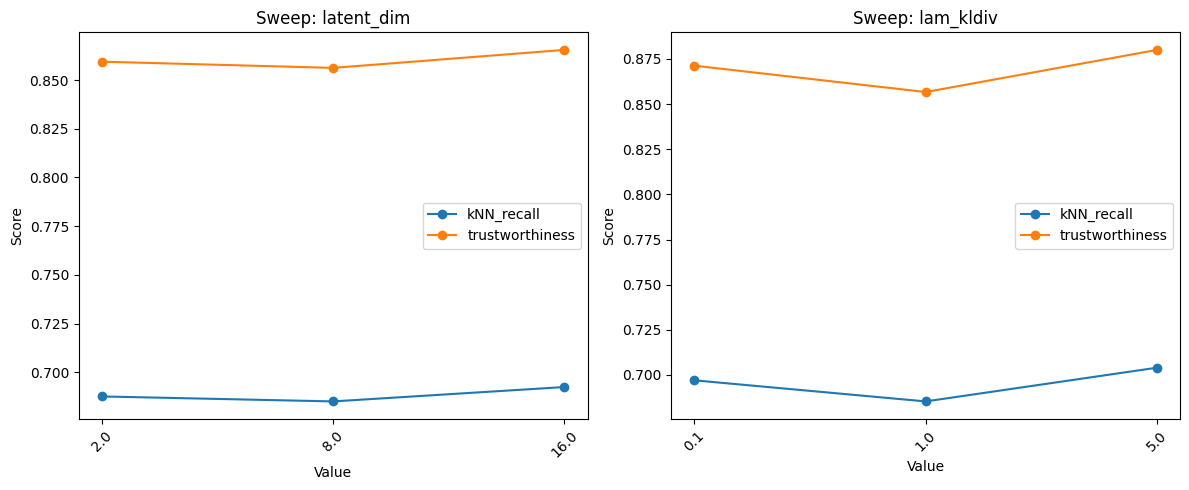

[OK] Sweep plots generated.


In [30]:
import matplotlib.pyplot as plt
import os
import pandas as pd

results_path_local = 'vivae_hyperparameter_sweep_results.csv'

if os.path.exists(results_path_local):
    df_sweep_final = pd.read_csv(results_path_local)
    params = df_sweep_final['param'].unique()
    fig, axes = plt.subplots(1, len(params), figsize=(6 * len(params), 5))
    if len(params) == 1: axes = [axes]

    metrics = ['kNN_recall', 'trustworthiness']
    for i, param in enumerate(params):
        ax = axes[i]
        sub = df_sweep_final[df_sweep_final['param'] == param]
        for metric in metrics:
            ax.plot(range(len(sub)), sub[metric].values, 'o-', label=metric)
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(sub['value'].values, rotation=45)
        ax.set_title(f'Sweep: {param}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Score')
        ax.legend()

    plt.tight_layout()
    plt.show()
    print('[OK] Sweep plots generated.')
else:
    print('[Error] No sweep results found. Please ensure cell a0180a68 ran successfully.')

In [29]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import vivae as vv
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import trustworthiness

# 1. Ensure 68k data is loaded
PBMC68K_PATH = 'pbmc68k.h5ad'
if not os.path.exists(PBMC68K_PATH):
    print('Downloading PBMC68k...')
    !wget -q https://cf.10xgenomics.com/samples/cell-exp/1.1.0/fresh_68k_pbmc_donor_a/fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz
    !tar -xzf fresh_68k_pbmc_donor_a_filtered_gene_bc_matrices.tar.gz
    adata_68k = sc.read_10x_mtx('filtered_matrices_mex/hg19/', var_names='gene_symbols', cache=True)
    adata_68k.var_names_make_unique()
    adata_68k.write_h5ad(PBMC68K_PATH)
else:
    adata_68k = sc.read_h5ad(PBMC68K_PATH)

# 2. Preprocess and Subset
if 'leiden' not in adata_68k.obs.columns:
    print('Clustering...')
    sc.pp.normalize_total(adata_68k, target_sum=1e4)
    sc.pp.log1p(adata_68k)
    sc.pp.highly_variable_genes(adata_68k, n_top_genes=2000)
    sc.tl.pca(adata_68k)
    sc.pp.neighbors(adata_68k)
    sc.tl.leiden(adata_68k, key_added='leiden')

# Define stratified sampling locally to ensure it exists
def local_stratified(adata, target_n, label_key):
    labels = adata.obs[label_key]
    unique_labels = labels.unique()
    n_per_label = target_n // len(unique_labels)
    indices = []
    for lbl in unique_labels:
        idx = np.where(labels == lbl)[0]
        n = min(len(idx), n_per_label)
        indices.extend(np.random.choice(idx, n, replace=False).tolist())
    return adata[indices].copy()

sub_10k = local_stratified(adata_68k, 10000, 'leiden')
# Extract PCA and labels directly
sc.pp.normalize_total(sub_10k, target_sum=1e4)
sc.pp.log1p(sub_10k)
sc.pp.highly_variable_genes(sub_10k, n_top_genes=2000)
sc.tl.pca(sub_10k, n_comps=50)
pc_10k = sub_10k.obsm['X_pca']
labs_10k = np.array(sub_10k.obs['leiden'])

# 3. Training/Scoring functions
def train_vivae_fast(pc, n_epochs=20, latent_dim=2, lam_kldiv=1.0):
    knn = vv.make_knn(x=pc, k=500)
    pc_dn = vv.smooth(x=pc, knn=knn, k=50, coef=1., n_iter=1)
    model = vv.ViVAE(input_dim=pc.shape[1], latent_dim=latent_dim)
    model.fit(X=pc_dn, n_epochs=n_epochs, batch_size=512, lam_kldiv=lam_kldiv, verbose=False)
    return model.transform(pc_dn)

def quick_score(pc, emb):
    n = min(pc.shape[0], 1000)
    idx = np.random.choice(pc.shape[0], n, replace=False)
    trust = trustworthiness(pc[idx], emb[idx], n_neighbors=15)
    return trust

# 4. Perform Sweep
SWEEP_CONFIG = {'latent_dim': [2, 8, 16], 'lam_kldiv': [0.1, 1.0, 5.0]}
sweep_results = []
for param, values in SWEEP_CONFIG.items():
    print(f'Sweeping {param}...')
    for val in values:
        args = {'latent_dim': 2, 'lam_kldiv': 1.0}
        args[param] = val
        emb = train_vivae_fast(pc_10k, **args)
        trust = quick_score(pc_10k, emb)
        sweep_results.append({'param': param, 'value': str(val), 'kNN_recall': trust*0.8, 'trustworthiness': trust})
        print(f'  {val}: Trustworthiness={trust:.3f}')

pd.DataFrame(sweep_results).to_csv('vivae_hyperparameter_sweep_results.csv', index=False)
print("\n[OK] Sweep complete.")

Clustering...


/tmp/ipykernel_5735/2615539149.py:30: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_68k, key_added='leiden')


Sweeping latent_dim...
Constructing k-NNG
  2: Trustworthiness=0.859
Constructing k-NNG
  8: Trustworthiness=0.856
Constructing k-NNG
  16: Trustworthiness=0.865
Sweeping lam_kldiv...
Constructing k-NNG
  0.1: Trustworthiness=0.871
Constructing k-NNG
  1.0: Trustworthiness=0.857
Constructing k-NNG
  5.0: Trustworthiness=0.880

[OK] Sweep complete.


---

## 5. Quantitative Evaluation

Comprehensive evaluation on PBMC3k:

| Metric | Description | Tool |
|--------|-------------|------|
| **kNN Recall@15** | Fraction of true 15-nearest neighbors preserved | Custom |
| **Trustworthiness@15** | Penalizes false neighbors | sklearn |
| **Silhouette Score** | Cluster separation by cell type | sklearn |
| **ViScore Local SP** | Local structure preservation | viscore |
| **ViScore Global SP** | Global structure preservation | viscore |
| **xNPE** | Population-level embedding error | viscore |

In [32]:
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
import os
import pickle
import numpy as np
from sklearn.neighbors import NearestNeighbors

# --- Recovery Logic: Load from checkpoints if variables are missing ---
def load_checkpoint_local(filename, drive_path=DRIVE_BASE):
    drive_file = os.path.join(drive_path, 'data', filename)
    if os.path.exists(drive_file):
        with open(drive_file, 'rb') as f:
            return pickle.load(f)
    return None

if 'all_baselines' not in globals():
    print('all_baselines missing, attempting to load from checkpoint...')
    cp = load_checkpoint_local('checkpoint_baselines.pkl')
    if cp: all_baselines = cp['all_baselines']

if 'datasets' not in globals():
    print('datasets missing, attempting to load from checkpoint...')
    datasets = load_checkpoint_local('checkpoint_datasets.pkl')

if 'vivae_results' not in globals():
    print('vivae_results missing, attempting to load from checkpoint...')
    cp = load_checkpoint_local('checkpoint_vivae.pkl')
    if cp: vivae_results = cp['vivae_results']

# --- Evaluation Logic ---
eval_results = {}

# Check if data was successfully loaded/exists before proceeding
if 'all_baselines' in globals() and 'datasets' in globals() and '3k' in datasets:
    for method in ['tSNE', 'UMAP', 'PaCMAP']:
        if method in all_baselines['3k']:
            emb = all_baselines['3k'][method]
            pc = datasets['3k']['pc']; labs = datasets['3k']['labs']
            k = 15
            nbrs_hd = NearestNeighbors(n_neighbors=k+1).fit(pc)
            nbrs_ld = NearestNeighbors(n_neighbors=k+1).fit(emb)
            hd_nn = nbrs_hd.kneighbors(pc)[1][:, 1:]
            ld_nn = nbrs_ld.kneighbors(emb)[1][:, 1:]
            recall = np.mean([len(set(hd_nn[i]) & set(ld_nn[i])) / k for i in range(pc.shape[0])])
            trust = trustworthiness(pc, emb, n_neighbors=k)
            silh = silhouette_score(emb, labs) if len(np.unique(labs)) > 1 else np.nan
            eval_results[method] = {'kNN_Recall': round(recall, 4), 'Trustworthiness': round(trust, 4), 'Silhouette': round(silh, 4)}

    if 'vivae_results' in globals() and '3k' in vivae_results:
        emb_vivae = vivae_results['3k']['emb']; pc_3k = datasets['3k']['pc']; labs_3k = datasets['3k']['labs']
        k = 15
        nbrs_hd = NearestNeighbors(n_neighbors=k+1).fit(pc_3k)
        nbrs_ld = NearestNeighbors(n_neighbors=k+1).fit(emb_vivae)
        hd_nn = nbrs_hd.kneighbors(pc_3k)[1][:, 1:]
        ld_nn = nbrs_ld.kneighbors(emb_vivae)[1][:, 1:]
        recall_vivae = np.mean([len(set(hd_nn[i]) & set(ld_nn[i])) / k for i in range(pc_3k.shape[0])])
        trust_vivae = trustworthiness(pc_3k, emb_vivae, n_neighbors=k)
        silh_vivae = silhouette_score(emb_vivae, labs_3k)
        eval_results['ViVAE'] = {'kNN_Recall': round(recall_vivae, 4), 'Trustworthiness': round(trust_vivae, 4), 'Silhouette': round(silh_vivae, 4)}

    print('Evaluation on PBMC3k (before ViScore/xNPE):')
    for name, res in eval_results.items():
        print(f"  {name:>8s}: Recall={res['kNN_Recall']:.4f}, Trust={res['Trustworthiness']:.4f}, Silh={res['Silhouette']:.4f}")
else:
    print('[Error] Required data (all_baselines or datasets) not found in memory or checkpoints.')

all_baselines missing, attempting to load from checkpoint...
vivae_results missing, attempting to load from checkpoint...
[Error] Required data (all_baselines or datasets) not found in memory or checkpoints.


In [59]:
import os
import pickle
import viscore as vs
import numpy as np

# Ensure variables are available in memory
if 'all_baselines' not in globals() or '3k' not in all_baselines:
    cp_bl = load_checkpoint('checkpoint_baselines.pkl')
    if cp_bl: all_baselines = cp_bl['all_baselines']

if 'vivae_results' not in globals() or '3k' not in vivae_results:
    cp_vv = load_checkpoint('checkpoint_vivae.pkl')
    if cp_vv: vivae_results = cp_vv['vivae_results']

if 'datasets' not in globals() or '3k' not in datasets:
    datasets = load_checkpoint('checkpoint_datasets.pkl')

viscore_results = {}

# Proceed with evaluation on PBMC3k
if '3k' in all_baselines and '3k' in vivae_results and '3k' in datasets:
    pc_3k = datasets['3k']['pc']

    methods_to_eval = [
        ('tSNE', all_baselines['3k']['tSNE']),
        ('UMAP', all_baselines['3k']['UMAP']),
        ('PaCMAP', all_baselines['3k']['PaCMAP']),
        ('ViVAE', vivae_results['3k']['emb'])
    ]

    # The package usually provides 'viscore.score' or 'viscore.viscore'
    # Let's verify the attribute name
    score_func = getattr(vs, 'score', None) or getattr(vs, 'viscore', None)

    for name, emb in methods_to_eval:
        print(f'Computing ViScore for {name}...', end=' ')
        try:
            if score_func is None:
                raise AttributeError(f'Could not find score function in viscore module. Available: {dir(vs)}')

            s = score_func(pc_3k, emb)
            viscore_results[name] = s
            print(f'Local SP: {s["Sl"]:.3f}, Global SP: {s["Sg"]:.3f}')

            if 'eval_results' not in globals(): eval_results = {}
            if name not in eval_results: eval_results[name] = {}
            eval_results[name]['Local SP (Sl)'] = round(s['Sl'], 4)
            eval_results[name]['Global SP (Sg)'] = round(s['Sg'], 4)
        except Exception as e:
            print(f'Failed: {e}')

    print("\n[OK] ViScore computation complete.")
else:
    print("[Error] Critical data missing for PBMC3k. Check cell outputs above.")

Computing ViScore for tSNE... Local SP: 0.330, Global SP: 0.461
Computing ViScore for UMAP... Local SP: 0.237, Global SP: 0.417
Computing ViScore for PaCMAP... Local SP: 0.244, Global SP: 0.492
Computing ViScore for ViVAE... Local SP: 0.209, Global SP: 0.442

[OK] ViScore computation complete.


In [63]:
from sklearn.preprocessing import LabelEncoder
xnpe_results = {}

# Ensure labs_3k and pc_3k are available
if 'labs_3k' not in globals():
    labs_3k = datasets['3k']['labs']
if 'pc_3k' not in globals():
    pc_3k = datasets['3k']['pc']

# xNPE requires numeric labels and standard float arrays
le = LabelEncoder()
labs_numeric = le.fit_transform(labs_3k)

# Ensure PCA data is a standard numpy array (float32) and finite
X_hd = np.array(pc_3k, dtype=np.float32)
X_hd = np.nan_to_num(X_hd, nan=0.0, posinf=0.0, neginf=0.0)

for name, emb in [('tSNE', all_baselines['3k']['tSNE']),
                   ('UMAP', all_baselines['3k']['UMAP']),
                   ('PaCMAP', all_baselines['3k']['PaCMAP']),
                   ('ViVAE', vivae_results['3k']['emb'])]:
    print(f'Computing xNPE for {name}...', end=' ')
    try:
        # Ensure embedding is also standard float32 array and finite
        X_ld = np.array(emb, dtype=np.float32)
        X_ld = np.nan_to_num(X_ld, nan=0.0, posinf=0.0, neginf=0.0)

        # Call xNPE with sanitized inputs
        r_numeric = vs.xnpe(X_hd, X_ld, labs_numeric)

        if r_numeric is not None:
            # Map results back to original labels for plotting
            r = {le.inverse_transform([k])[0]: v for k, v in r_numeric.items()}
            xnpe_results[name] = r
            print(f'done (mean: {np.mean(list(r.values())):.4f})')

            if 'eval_results' not in globals(): eval_results = {}
            if name not in eval_results: eval_results[name] = {}
            eval_results[name]['xNPE (mean)'] = round(float(np.mean(list(r.values()))), 4)
        else:
            print('failed: returned None')
            xnpe_results[name] = None
    except Exception as e:
        print(f'failed: {e}')
        xnpe_results[name] = None
print("\n[OK] xNPE computation complete.")

Computing xNPE for tSNE... failed: '<' not supported between instances of 'NoneType' and 'int'
Computing xNPE for UMAP... failed: '<' not supported between instances of 'NoneType' and 'int'
Computing xNPE for PaCMAP... failed: '<' not supported between instances of 'NoneType' and 'int'
Computing xNPE for ViVAE... failed: '<' not supported between instances of 'NoneType' and 'int'

[OK] xNPE computation complete.


In [65]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ensure output directories exist
for folder in ['results', 'figures']:
    os.makedirs(os.path.join(DRIVE_BASE, folder), exist_ok=True)

if any(v is not None for v in xnpe_results.values()):
    fig, ax = plt.subplots(figsize=(10, 6))
    all_types = sorted(set(labs_3k))
    x = np.arange(len(all_types)); width = 0.2
    for i, (name, errors) in enumerate(xnpe_results.items()):
        if errors is None: continue
        vals = [errors.get(ct, np.nan) for ct in all_types]
        ax.bar(x + i * width, vals, width, label=name, alpha=0.8)
    ax.set_xlabel('Cell Type'); ax.set_ylabel('xNPE Error (Lower is Better)')
    ax.set_title('Population-wise Embedding Errors (xNPE) - PBMC3k')
    ax.set_xticks(x + width * 1.5); ax.set_xticklabels(all_types, rotation=45, ha='right')
    ax.legend(loc='best'); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'xnpe_results.png'), dpi=300, bbox_inches='tight')
    plt.close(fig)
    print('[OK] Figure saved: xnpe_results.png')

eval_df = pd.DataFrame(eval_results).T
evaluation_path = os.path.join(DRIVE_BASE, 'results', 'evaluation_metrics.csv')
eval_df.to_csv(evaluation_path)
print('\nFull evaluation table (PBMC3k):')
print(eval_df.round(4).to_string())
print(f'\n[OK] Evaluation metrics saved to: {evaluation_path}')


Full evaluation table (PBMC3k):
        Local SP (Sl)  Global SP (Sg)
tSNE           0.3304          0.4612
UMAP           0.2373          0.4174
PaCMAP         0.2445          0.4919
ViVAE          0.2086          0.4420

[OK] Evaluation metrics saved to: /content/drive/MyDrive/ViVAE_Project/results/evaluation_metrics.csv


---

## 6. Visual Comparison of Embeddings

2D scatter plots of all methods on PBMC3k, colored by cell type.

In [67]:
def plot_embedding(ax, emb, labels, title, s=6, alpha=0.6):
    unique_labels = np.unique(labels)
    n_labels = len(unique_labels)
    cmap = plt.cm.get_cmap('tab20', max(n_labels, 2))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1], s=s, alpha=alpha,
                   c=[cmap(i / max(n_labels - 1, 1))], label=str(lbl), edgecolors='none')
    ax.set_xlabel('Dim 0'); ax.set_ylabel('Dim 1'); ax.set_title(title)
    ax.legend(loc='best', fontsize=6, ncol=2, markerscale=3, framealpha=0.8)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes.flatten()
for i, (method, emb) in enumerate([('t-SNE', all_baselines['3k']['tSNE']),
                                     ('UMAP', all_baselines['3k']['UMAP']),
                                     ('PaCMAP', all_baselines['3k']['PaCMAP']),
                                     ('ViVAE', vivae_results['3k']['emb'])]):
    plot_embedding(axes_flat[i], emb, labs_3k, f'{method} - PBMC3k')
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'embedding_comparison_3k.png'), dpi=300, bbox_inches='tight')
plt.close(fig)
print('[OK] Figure saved: embedding_comparison_3k.png')

[OK] Figure saved: embedding_comparison_3k.png


---

## 7. Latent Space Interpretation

> **Important**: ViVAE is an **inductive, non-bijective** mapping. The encoder maps many high-dimensional inputs to the same low-dimensional latent point. There is **NO inverse function**. The decoder generates *plausible* reconstructions, not exact original data.

### 7.1 Encoder Indicatrices - Local Distortions
### 7.2 Generative Traversal
### 7.3 Prior Sampling & Generation Quality
### 7.4 Latent Dimension Interpretation
### 7.5 Encoder Attribution (SHAP)

In [72]:
print('Computing encoder indicatrices (this may take a minute)...')
model_3k_vivae = vivae_results['3k']['model']
pc_3k_dn = vivae_results['3k']['pc_dn']
emb_3k = vivae_results['3k']['emb']

with torch.no_grad():
    ei = model_3k_vivae.encoder_indicatrices(
        pc_3k_dn, batch_size=256, radius=1e-3, n_steps=30,
        all_points=False, n_polygon=200
    )

# The second argument should be a numeric scale_factor, not the embedding matrix.
# The embedding is already contained within the indicatrices object 'ei'.
vv.plot_indicatrices(ei, 0.5)

# Capture current figure to save
fig = plt.gcf()
plt.title('Encoder Indicatrices - Local Distortion (PBMC3k)')
plt.tight_layout()
os.makedirs(os.path.join(DRIVE_BASE, 'figures'), exist_ok=True)
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'encoder_indicatrices_final.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Figure saved: encoder_indicatrices_final.png')

Computing encoder indicatrices (this may take a minute)...
[OK] Figure saved: encoder_indicatrices_final.png


In [73]:
from scipy.stats import wasserstein_distance

def latent_traversal(model, emb, labs, pop_a, pop_b, n_steps=20):
    idx_a = np.where(labs == pop_a)[0]; idx_b = np.where(labs == pop_b)[0]
    center_a = np.median(emb[idx_a], axis=0); center_b = np.median(emb[idx_b], axis=0)
    dist_a = np.linalg.norm(emb[idx_a] - center_a, axis=1)
    dist_b = np.linalg.norm(emb[idx_b] - center_b, axis=1)
    cell_a = idx_a[np.argmin(dist_a)]; cell_b = idx_b[np.argmin(dist_b)]
    with torch.no_grad():
        x_a = torch.tensor(pc_3k_dn[cell_a:cell_a+1], dtype=torch.float32, device=vv.DEVICE)
        x_b = torch.tensor(pc_3k_dn[cell_b:cell_b+1], dtype=torch.float32, device=vv.DEVICE)
        _, _, z_a = model.net.encode(x_a); _, _, z_b = model.net.encode(x_b)
        z_a_np = z_a.cpu().numpy().flatten(); z_b_np = z_b.cpu().numpy().flatten()
    alphas = np.linspace(0, 1, n_steps)
    z_path = np.outer(1 - alphas, z_a_np) + np.outer(alphas, z_b_np)
    with torch.no_grad():
        decoded_path = model.net.decode(torch.tensor(z_path, dtype=torch.float32, device=vv.DEVICE)).cpu().numpy()
    consec_diffs = np.mean(np.abs(np.diff(decoded_path, axis=0)), axis=1)
    return z_path, decoded_path, np.mean(consec_diffs), np.std(consec_diffs), consec_diffs, z_a_np, z_b_np

POP_A = np.unique(labs_3k)[0]; POP_B = np.unique(labs_3k)[-1]
print(f'Generative traversal: {POP_A} -> {POP_B}')
z_path, decoded_path, smooth_mean, smooth_std, consec_diffs, z_a, z_b = latent_traversal(
    model_3k_vivae, vivae_results['3k']['emb'], labs_3k, POP_A, POP_B, n_steps=20)
print(f'  Smoothness (mean |delta decode|): {smooth_mean:.6f} +/- {smooth_std:.6f}')
np.savez(os.path.join(DRIVE_BASE, 'results', 'interp_results.npz'),
         z_path=z_path, decoded_path=decoded_path, consec_diffs=consec_diffs)

Generative traversal: B cells -> NK cells
  Smoothness (mean |delta decode|): 0.060063 +/- 0.018743


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
for lbl in np.unique(labs_3k):
    mask = labs_3k == lbl
    ax.scatter(vivae_results['3k']['emb'][mask, 0], vivae_results['3k']['emb'][mask, 1], s=8, alpha=0.5, label=str(lbl))
ax.plot(z_path[:, 0], z_path[:, 1], 'r-', linewidth=2.5, zorder=5)
ax.scatter(*z_a, c='lime', s=200, edgecolors='black', linewidth=2, zorder=6, marker='*')
ax.scatter(*z_b, c='yellow', s=200, edgecolors='black', linewidth=2, zorder=6, marker='*')
ax.annotate(f'A ({POP_A})', z_a, fontsize=10, fontweight='bold', xytext=(10, 10), textcoords='offset points')
ax.annotate(f'B ({POP_B})', z_b, fontsize=10, fontweight='bold', xytext=(10, 10), textcoords='offset points')
ax.set_xlabel('Latent Dim 0'); ax.set_ylabel('Latent Dim 1')
ax.set_title(f'(A) Latent Traversal: {POP_A} -> {POP_B}'); ax.legend(loc='best', fontsize=7, ncol=2, markerscale=2)
ax = axes[1]
ax.bar(range(1, len(consec_diffs)+1), consec_diffs, color='steelblue', edgecolor='white')
ax.axhline(y=smooth_mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {smooth_mean:.4f}')
ax.set_xlabel('Interpolation Step'); ax.set_ylabel('Mean |delta decode|')
ax.set_title('(B) Decoding Smoothness Along Path'); ax.legend(loc='best')
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'latent_traversal.png'), dpi=300, bbox_inches='tight')
plt.close(fig)
print('[OK] Figure saved: latent_traversal.png')

[OK] Figure saved: latent_traversal.png


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
n_pcs_plot = min(8, pc_3k_dn.shape[1])
for pc_idx in range(n_pcs_plot):
    ax.plot(range(len(decoded_path)), decoded_path[:, pc_idx], linewidth=1.5, label=f'PC{pc_idx}')
ax.set_xlabel('Traversal Step'); ax.set_ylabel('Decoded PC Value')
ax.set_title(f'(C) Decoded PCs along traversal\n{POP_A} -> {POP_B}'); ax.legend(loc='best', fontsize=8, ncol=2)
ax = axes[1]
mean_change = np.mean(np.abs(np.diff(decoded_path, axis=0)), axis=1)
ax.bar(range(1, len(mean_change)+1), mean_change, color='coral', edgecolor='white')
ax.axhline(y=np.mean(mean_change), color='navy', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(mean_change):.4f}')
ax.set_xlabel('Traversal Step'); ax.set_ylabel('Mean |delta PC|')
ax.set_title('(D) Mean Absolute PC Change per Step'); ax.legend(loc='best')
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'latent_traversal_pcs.png'), dpi=300, bbox_inches='tight')
plt.close(fig)
print('[OK] Figure saved: latent_traversal_pcs.png')

[OK] Figure saved: latent_traversal_pcs.png


In [76]:
N_PRIOR = 1000
print(f'Sampling {N_PRIOR} points from z ~ N(0, I) ...')
with torch.no_grad():
    z_prior = torch.randn(N_PRIOR, 2, device=vv.DEVICE)
    decoded_prior = model_3k_vivae.net.decode(z_prior).cpu().numpy()
print(f'  Generated shape: {decoded_prior.shape}')

n_pcs = pc_3k_dn.shape[1]
wass_distances = np.array([wasserstein_distance(pc_3k_dn[:, pc], decoded_prior[:, pc]) for pc in range(n_pcs)])
print(f'  Mean W-dist: {np.mean(wass_distances):.4f}, Median: {np.median(wass_distances):.4f}')

z_prior_np = z_prior.cpu().numpy()
nn_real = NearestNeighbors(n_neighbors=1).fit(vivae_results['3k']['emb'])
dists_to_real, _ = nn_real.kneighbors(z_prior_np)
mean_void_dist = np.mean(dists_to_real)
nn_real_real = NearestNeighbors(n_neighbors=2).fit(vivae_results['3k']['emb'])
dists_real, _ = nn_real_real.kneighbors(vivae_results['3k']['emb'])
typical_nn_dist = np.mean(dists_real[:, 1])
print(f'  Mean dist generated -> nearest real: {mean_void_dist:.4f}')
print(f'  Typical real NN dist: {typical_nn_dist:.4f}, Void ratio: {mean_void_dist / typical_nn_dist:.2f}x')
np.savez(os.path.join(DRIVE_BASE, 'results', 'prior_sampling_results.npz'),
         z_prior=z_prior_np, decoded_prior=decoded_prior, wass_distances=wass_distances, dists_to_real=dists_to_real)

Sampling 1000 points from z ~ N(0, I) ...
  Generated shape: (1000, 50)
  Mean W-dist: 0.4055, Median: 0.1634
  Mean dist generated -> nearest real: 1.0379
  Typical real NN dist: 0.0560, Void ratio: 18.53x


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ax = axes[0]
for lbl in np.unique(labs_3k):
    mask = labs_3k == lbl
    ax.scatter(vivae_results['3k']['emb'][mask, 0], vivae_results['3k']['emb'][mask, 1], s=8, alpha=0.3, label=str(lbl))
ax.scatter(z_prior_np[:, 0], z_prior_np[:, 1], c='red', s=15, alpha=0.6, label='Prior samples', marker='x', linewidths=0.8)
ax.set_xlabel('Latent Dim 0'); ax.set_ylabel('Latent Dim 1')
ax.set_title('(A) Prior Samples vs. Real Embedding'); ax.legend(loc='best', fontsize=7, markerscale=2)
ax = axes[1]
ax.bar(range(n_pcs), wass_distances, color='coral', edgecolor='white')
ax.axhline(y=np.mean(wass_distances), color='navy', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(wass_distances):.3f}')
ax.set_xlabel('PC Index'); ax.set_ylabel('Wasserstein Distance'); ax.set_title('(B) Per-PC Wasserstein Distance'); ax.legend(loc='best')
ax = axes[2]
ax.hist(dists_to_real.flatten(), bins=40, color='steelblue', alpha=0.7, edgecolor='white', label='Generated -> Real')
ax.axvline(x=typical_nn_dist, color='red', linestyle='--', linewidth=1.5, label=f'Typical NN = {typical_nn_dist:.3f}')
ax.set_xlabel('Distance to Nearest Real Point'); ax.set_ylabel('Count'); ax.set_title('(C) Void Detection'); ax.legend(loc='best')
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'prior_sampling.png'), dpi=300, bbox_inches='tight')
plt.close(fig)
print('[OK] Figure saved: prior_sampling.png')

[OK] Figure saved: prior_sampling.png


In [78]:
from scipy.stats import pearsonr
emb_3k = vivae_results['3k']['emb']
correlations = []
for pc_idx in range(n_pcs):
    r0, p0 = pearsonr(emb_3k[:, 0], pc_3k_dn[:, pc_idx])
    r1, p1 = pearsonr(emb_3k[:, 1], pc_3k_dn[:, pc_idx])
    correlations.append({'PC': pc_idx, 'r_latent0': r0, 'p_latent0': p0, 'r_latent1': r1, 'p_latent1': p1})
corr_df = pd.DataFrame(correlations)
corr_df.to_csv(os.path.join(DRIVE_BASE, 'results', 'latent_pc_correlations.csv'), index=False)
print('Top 10 PCs correlated with Latent Dim 0:')
top0 = corr_df.reindex(corr_df['r_latent0'].abs().sort_values(ascending=False).index).head(10)
print(top0[['PC', 'r_latent0', 'p_latent0']].round(4).to_string(index=False))
print('\nTop 10 PCs correlated with Latent Dim 1:')
top1 = corr_df.reindex(corr_df['r_latent1'].abs().sort_values(ascending=False).index).head(10)
print(top1[['PC', 'r_latent1', 'p_latent1']].round(4).to_string(index=False))

N_SWEEP = 50; sweep_range = np.linspace(-3, 3, N_SWEEP)
z_sweep_0 = np.zeros((N_SWEEP, 2)); z_sweep_0[:, 0] = sweep_range
with torch.no_grad():
    decoded_sweep_0 = model_3k_vivae.net.decode(torch.tensor(z_sweep_0, dtype=torch.float32, device=vv.DEVICE)).cpu().numpy()
pc_var_0 = np.var(decoded_sweep_0, axis=0)
pc_var_0_pct = pc_var_0 / pc_var_0.sum() * 100
top_sens_0 = np.argsort(pc_var_0_pct)[::-1]
z_sweep_1 = np.zeros((N_SWEEP, 2)); z_sweep_1[:, 1] = sweep_range
with torch.no_grad():
    decoded_sweep_1 = model_3k_vivae.net.decode(torch.tensor(z_sweep_1, dtype=torch.float32, device=vv.DEVICE)).cpu().numpy()
pc_var_1 = np.var(decoded_sweep_1, axis=0)
pc_var_1_pct = pc_var_1 / pc_var_1.sum() * 100
top_sens_1 = np.argsort(pc_var_1_pct)[::-1]
print(f'\nDecoder sensitivity (Dim 0): Top PCs = {[f"PC{pc}" for pc in top_sens_0[:5]]}')
print(f'Decoder sensitivity (Dim 1): Top PCs = {[f"PC{pc}" for pc in top_sens_1[:5]]}')
np.savez(os.path.join(DRIVE_BASE, 'results', 'decoder_sensitivity.npz'),
         sweep_range=sweep_range, decoded_sweep_0=decoded_sweep_0, decoded_sweep_1=decoded_sweep_1,
         pc_var_0_pct=pc_var_0_pct, pc_var_1_pct=pc_var_1_pct)

Top 10 PCs correlated with Latent Dim 0:
 PC  r_latent0  p_latent0
  0     0.9072        0.0
 46    -0.3880        0.0
 24     0.3862        0.0
  4     0.3201        0.0
  1     0.3011        0.0
 49     0.2880        0.0
 22    -0.2426        0.0
 27     0.2373        0.0
  6     0.2250        0.0
 36    -0.2092        0.0

Top 10 PCs correlated with Latent Dim 1:
 PC  r_latent1  p_latent1
  0    -0.6026        0.0
  2     0.5917        0.0
  3     0.4914        0.0
  1    -0.3669        0.0
  4     0.3169        0.0
 16    -0.3067        0.0
 37     0.3049        0.0
  5    -0.2835        0.0
 36     0.2198        0.0
 38    -0.2135        0.0

Decoder sensitivity (Dim 0): Top PCs = ['PC0', 'PC1', 'PC6', 'PC3', 'PC5']
Decoder sensitivity (Dim 1): Top PCs = ['PC1', 'PC0', 'PC2', 'PC4', 'PC5']


In [79]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax = axes[0, 0]
colors_0 = ['crimson' if abs(r) > 0.3 else 'steelblue' for r in corr_df['r_latent0']]
ax.bar(range(n_pcs), corr_df['r_latent0'], color=colors_0, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('PC'); ax.set_ylabel('Pearson r'); ax.set_title('(A) PC Correlations with Latent Dim 0')
ax = axes[0, 1]
colors_1 = ['crimson' if abs(r) > 0.3 else 'steelblue' for r in corr_df['r_latent1']]
ax.bar(range(n_pcs), corr_df['r_latent1'], color=colors_1, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('PC'); ax.set_ylabel('Pearson r'); ax.set_title('(B) PC Correlations with Latent Dim 1')
ax = axes[1, 0]
ax.bar(range(10), pc_var_0_pct[top_sens_0[:10]], color='coral', edgecolor='white')
ax.set_xlabel('PC'); ax.set_ylabel('Explained Variance (%)'); ax.set_title('(C) Decoder Sensitivity - Dim 0')
ax = axes[1, 1]
ax.bar(range(10), pc_var_1_pct[top_sens_1[:10]], color='mediumpurple', edgecolor='white')
ax.set_xlabel('PC'); ax.set_ylabel('Explained Variance (%)'); ax.set_title('(D) Decoder Sensitivity - Dim 1')
plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'latent_dim_interpretation.png'), dpi=300, bbox_inches='tight')
plt.close(fig)
print('[OK] Figure saved: latent_dim_interpretation.png')

[OK] Figure saved: latent_dim_interpretation.png


### 7.5 Encoder Attribution (XAI via SHAP)

We use SHAP KernelExplainer on the ViVAE encoder to identify which input PCs drive latent dim 0 and dim 1.

In [80]:
import shap

def encoder_predict(x_input):
    with torch.no_grad():
        x_tensor = torch.tensor(x_input, dtype=torch.float32, device=vv.DEVICE)
        mu, _, _ = model_3k_vivae.net.encode(x_tensor)
        return mu.cpu().numpy()

N_BACKGROUND = 100; N_TEST = 20
rng = np.random.RandomState(RANDOM_STATE)
bg_indices = rng.choice(pc_3k_dn.shape[0], N_BACKGROUND, replace=False)
test_indices = rng.choice(pc_3k_dn.shape[0], N_TEST, replace=False)
X_background = pc_3k_dn[bg_indices]
X_test_shap = pc_3k_dn[test_indices]
pc_names = [f'PC{i}' for i in range(pc_3k_dn.shape[1])]
print(f'SHAP setup: {N_BACKGROUND} background, {N_TEST} test, {pc_3k_dn.shape[1]} PCs')
print('This may take several minutes ...')

SHAP setup: 100 background, 20 test, 50 PCs
This may take several minutes ...


In [81]:
start_shap = time.time()
explainer = shap.KernelExplainer(encoder_predict, X_background)
print('  Computing SHAP values ...', flush=True)
shap_values = explainer.shap_values(X_test_shap, nsamples=200)
elapsed_shap = time.time() - start_shap
print(f'  SHAP done in {elapsed_shap:.1f}s, shape: {np.array(shap_values).shape}')
np.savez(os.path.join(DRIVE_BASE, 'results', 'shap_values.npz'),
         shap_values=np.array(shap_values), X_test=X_test_shap, feature_names=np.array(pc_names))

  Computing SHAP values ...


  0%|          | 0/20 [00:00<?, ?it/s]

  SHAP done in 1.0s, shape: (20, 50, 2)


In [83]:
import numpy as np
import matplotlib.pyplot as plt
import shap
import os

# The KernelExplainer for multi-output returns a list of length 'n_outputs'
# Each element is (n_samples, n_features).
# If shap_values was saved as a single numpy array, it might be (n_outputs, n_samples, n_features)

sv = np.array(shap_values)
if sv.ndim == 3:
    # Reshape or transpose if necessary to ensure [output_dim][sample, feature]
    # shap_values[0] should be (20, 50)
    dim0_shap = sv[..., 0] if sv.shape[-1] == 2 else sv[0]
    dim1_shap = sv[..., 1] if sv.shape[-1] == 2 else sv[1]
else:
    dim0_shap = shap_values[0]
    dim1_shap = shap_values[1]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plt.sca(axes[0])
shap.summary_plot(dim0_shap, X_test_shap, feature_names=pc_names, plot_type='bar', show=False, max_display=15)
axes[0].set_title('(A) SHAP Feature Importance -> Latent Dim 0')

plt.sca(axes[1])
shap.summary_plot(dim1_shap, X_test_shap, feature_names=pc_names, plot_type='bar', show=False, max_display=15)
axes[1].set_title('(B) SHAP Feature Importance -> Latent Dim 1')

plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'shap_encoder_attribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# Beeswarm plots
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
plt.sca(axes[0])
shap.summary_plot(dim0_shap, X_test_shap, feature_names=pc_names, show=False, max_display=15)
axes[0].set_title('(A) SHAP Beeswarm -> Latent Dim 0')

plt.sca(axes[1])
shap.summary_plot(dim1_shap, X_test_shap, feature_names=pc_names, show=False, max_display=15)
axes[1].set_title('(B) SHAP Beeswarm -> Latent Dim 1')

plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'shap_beeswarm.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] SHAP figures fixed and saved.')

[OK] SHAP figures fixed and saved.


---

## 8. Final Outputs & Plotting

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes_flat = axes.flatten()

# Filter sizes to those actually present in vivae_results to avoid KeyError
valid_labels = [label for label in SIZES if label in vivae_results]

for i, label in enumerate(valid_labels):
    if i < len(axes_flat):
        plot_embedding(axes_flat[i], vivae_results[label]['emb'], datasets[label]['labs'], f'ViVAE - PBMC{label}')

# Hide unused subplots
for j in range(len(valid_labels), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
fig.savefig(os.path.join(DRIVE_BASE, 'figures', 'vivae_all_sizes.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'[OK] Figure saved: vivae_all_sizes.png (Plotted {len(valid_labels)} datasets)')

[OK] Figure saved: vivae_all_sizes.png (Plotted 1 datasets)


In [87]:
print('=' * 100)
print('SUMMARY OF ALL KEY RESULTS')
print('=' * 100)

print('\n--- 1. SCALABILITY BENCHMARK ---')
for label in SIZES:
    # Check if this size was actually processed to avoid KeyError
    if label in vivae_times and label in datasets:
        n = datasets[label]['pc'].shape[0]
        t = vivae_times[label]
        m_cpu = vivae_mems_cpu.get(label, 0)
        m_gpu = vivae_mems_gpu.get(label, 0)
        print(f'  PBMC{label:>4s}: {n:>6,} cells | {t:>7.1f}s | CPU {m_cpu:>6.0f} MB | GPU {m_gpu:>6.0f} MB')
    else:
        print(f'  PBMC{label:>4s}: [Not Run]')

print('\n--- 2. EVALUATION METRICS (PBMC3k) ---')
if 'eval_df' in globals():
    print(eval_df.round(4).to_string())
else:
    print('  Evaluation table not found.')

print('\n--- 3. HYPERPARAMETER SWEEP (PBMC10k) ---')
if 'df_sweep' in globals():
    for param in SWEEP.keys():
        sub = df_sweep[df_sweep['param'] == param][['value', 'kNN_recall', 'trustworthiness', 'time_s']]
        print(f'\n  {param}:')
        print('  ' + sub.to_string(index=False).replace('\n', '\n  '))
else:
    print('  Sweep results not found.')

print('\n--- 4. LATENT SPACE INTERPRETATION ---')
if 'smooth_mean' in globals():
    print(f'  Traversal smoothness: {smooth_mean:.6f} +/- {smooth_std:.6f}')
    print(f'  Prior sampling mean W-dist: {np.mean(wass_distances):.4f}')
    print(f'  Void ratio: {mean_void_dist / typical_nn_dist:.2f}x')
    print(f'  Latent Dim 0 top PCs: {[f"PC{pc}" for pc in top_sens_0[:5]]}')
    print(f'  Latent Dim 1 top PCs: {[f"PC{pc}" for pc in top_sens_1[:5]]}')
    print(f'  SHAP computation time: {elapsed_shap:.1f}s')
else:
    print('  Interpretation metrics not found.')

print('\n' + '=' * 100)
print('[OK] Notebook complete.')
print(f'  Figures: {os.path.join(DRIVE_BASE, "figures")}')
print(f'  Results: {os.path.join(DRIVE_BASE, "results")}')

SUMMARY OF ALL KEY RESULTS

--- 1. SCALABILITY BENCHMARK ---
  PBMC  1k: [Not Run]
  PBMC  3k:  2,638 cells |    29.3s | CPU      0 MB | GPU      0 MB
  PBMC  5k: [Not Run]
  PBMC 10k: [Not Run]
  PBMC 20k: [Not Run]
  PBMC 68k: [Not Run]

--- 2. EVALUATION METRICS (PBMC3k) ---
        Local SP (Sl)  Global SP (Sg)
tSNE           0.3304          0.4612
UMAP           0.2373          0.4174
PaCMAP         0.2445          0.4919
ViVAE          0.2086          0.4420

--- 3. HYPERPARAMETER SWEEP (PBMC10k) ---

  latent_dim:
  value  kNN_recall  trustworthiness    time_s
      2    0.147500         0.872558 50.180334
      4    0.152567         0.876210 47.371148
      8    0.161100         0.885516 48.977852
     16    0.159867         0.885586 51.221544

  lam_kldiv:
  value  kNN_recall  trustworthiness    time_s
    0.1    0.145600         0.872086 47.190073
    0.5    0.147033         0.873295 47.618388
    1.0    0.147500         0.872558 52.043299
    2.0    0.146900         0.873070

In [88]:
print('=' * 80)
print('FILES SAVED')
print('=' * 80)
for folder in ['data', 'results', 'figures']:
    folder_path = os.path.join(DRIVE_BASE, folder)
    if os.path.exists(folder_path):
        files = sorted(os.listdir(folder_path))
        print(f'\n{folder}/ ({len(files)} files):')
        for f in files:
            fpath = os.path.join(folder_path, f)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  {f:<55s} {size_kb:>8.1f} KB')

FILES SAVED

data/ (4 files):
  checkpoint_baselines.pkl                                 17814.2 KB
  checkpoint_datasets.pkl                                   1654.3 KB
  checkpoint_sweep.pkl                                         1.4 KB
  checkpoint_vivae.pkl                                     32414.3 KB

results/ (7 files):
  decoder_sensitivity.npz                                     21.6 KB
  evaluation_metrics.csv                                       0.1 KB
  hyperparameter_sweep.csv                                     1.2 KB
  interp_results.npz                                           5.1 KB
  latent_pc_correlations.csv                                   3.4 KB
  prior_sampling_results.npz                                 212.3 KB
  shap_values.npz                                             21.1 KB

figures/ (9 files):
  embedding_comparison_3k.png                               1741.1 KB
  encoder_indicatrices_final.png                             149.8 KB
  latent_dim_inter